# Real pancreas dataset

## VelOT pipeline & imports

In [1]:
import velot
import scanpy as sc

import matplotlib.pyplot as plt

## Set-up parameters

Quick set-up parameters for cell-type cluster identification and velocity embedding projection as well as visualization configuration.

In [2]:
figures_path = None
show = True
save = False
basis = "pca"
project_umap = True if basis == "pca" else False
clusters_key = "clusters"

## Data loading & preprocessing

In [3]:
# Load data
try:
    adata = sc.read_h5ad("../../article/datasets/endocrinogenesis_day15.5_preprocessed.h5ad")
except:
    print("No downloaded file found, retrieving from scvelo...")
    adata = velot.datasets.pancreas()

# Preprocess
velot.pp.pca(adata, n_pcs=10)
sc.pp.neighbors(adata, 20, use_rep="X_pca")
velot.pp.pseudotime(adata, root_cluster="Ngn3 low EP", root_cell=77)
adata.obs["clusters_id"] = adata.obs[clusters_key].cat.codes

We can have a quick overviw of the dataset and the pseudotime computed using DPT.

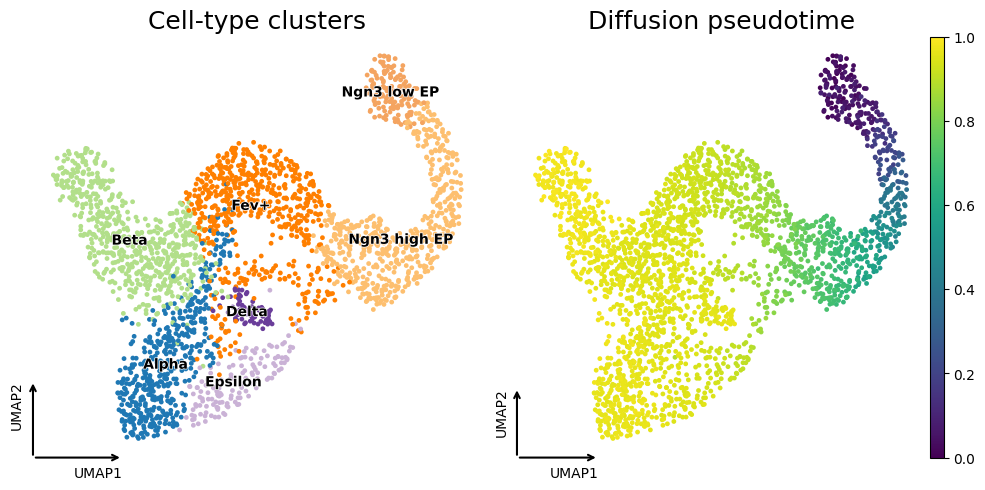

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

velot.pl.dataset_overview_simple(adata, color=clusters_key,
    title="Cell-type clusters", inframe=True,
    show=False, ax=axes[0]
)
velot.pl.dataset_overview_simple(adata, color="dpt_pseudotime",
    title="Diffusion pseudotime",
    show=False, ax=axes[1]
)

plt.tight_layout()
plt.show()

## Velocity field computation

Velocity computation can be done using the command `velot.tl.velocity()`. It will internally compute all the `VelOT` steps:
- Build pairs of windows
- Compute OT cost between windows
- Smooth raw OT velocity vectors
- Project the final field to UMAP embedding for visualization

In [ ]:
velot.tl.velocity(
    adata=adata,
    basis=f"X_{basis}",
    smooth=True,
    n_clusters=None,
    window_size=50,
    overlap_fraction=0,
    # spatial_key="clusters_id",
    reg=0.1, lambda_time=1, n_epochs=150, lambda_smooth=0.7, lambda_curl=0.7,
    project_umap=project_umap
)

VelOT: Computing velocity field
  Basis: X_pca (10D)
  Cells: 2531
  Smoothing: ON

[1/4] Building spatial-temporal windows...
  Spatial clustering: 25 clusters via KMeans on X_pca (10D)
  Built 48 window pairs across 25 clusters (skipped 0 small clusters)
  Window size: 50, step: 50

[2/4] Computing OT velocity...
  OT velocity computed: 2106 cells with velocity, 425 cells without (will be filled by smoothing)

[3/4] Smoothing velocity field...
Found torch compatible version. Running on cuda device
    epoch 50/150: total=1.1917 reg=5.1528 smooth=0.0015 curl=0.0002
    epoch 100/150: total=1.0527 reg=4.6819 smooth=0.0009 curl=0.0001
    epoch 150/150: total=1.1721 reg=5.2095 smooth=0.0010 curl=0.0001
  Smoothing complete: final total=1.1721

[4/4] Projecting to UMAP...
  Velocity projected to UMAP (2531 cells)
  Velocity projected to UMAP (2531 cells)

VelOT: Done.


AnnData object with n_obs × n_vars = 2531 × 2000
    obs: 'day', 'proliferation', 'G2M_score', 'S_score', 'phase', 'clusters_coarse', 'clusters', 'clusters_fine', 'louvain_Alpha', 'louvain_Beta', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'velocity_self_transition', 'dpt_pseudotime', 'pseudotime', 'clusters_id', 'velot_spatial_cluster', 'velot_confidence'
    var: 'highly_variable_genes', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'fit_r2', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'velocity_genes'
    uns: 'clusters_colors', 'clusters_fine_colors', 'diffmap_evals', 'iroot', 'louvain_Alpha_colors', 'louvain_Beta_colors', 'neighbors', 'pca', 'recover_dynamics', 'velocity_graph', 'velocity_graph_neg', 'velocity_params', 'velot_windows', 'velot_smoothing'
    o

## Visualization

There are multiple representations available in the pipeline. All of them are accessible via the `velot.pl` module.

### Velocity field stream

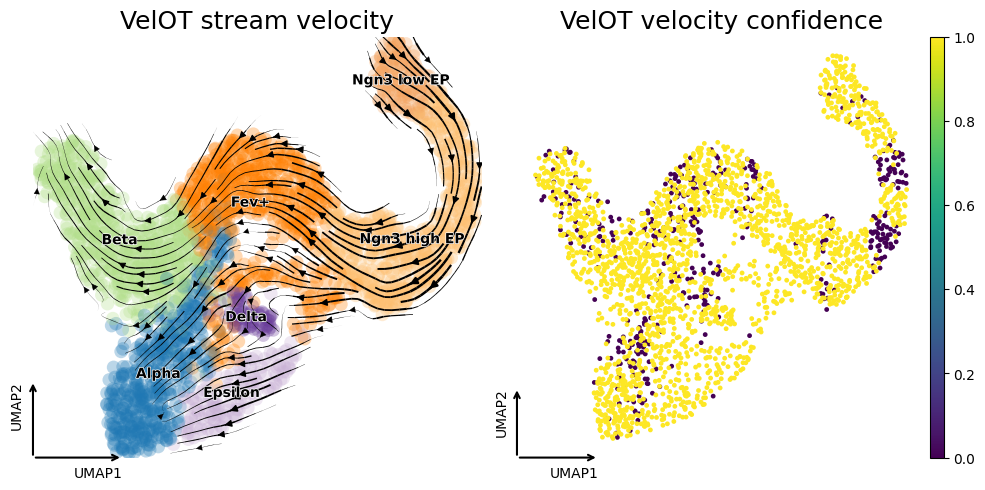

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

velot.pl.velocity_stream(adata, color=clusters_key,
    title="VelOT stream velocity",
    figsize=(5,5), show=False, ax=axes[0]
)
velot.pl.dataset_overview_simple(adata, color="velot_confidence",
    title="VelOT velocity confidence",
    show=False, ax=axes[1]
)

plt.tight_layout()
plt.show()

### Raw and smoothed velocity vectors

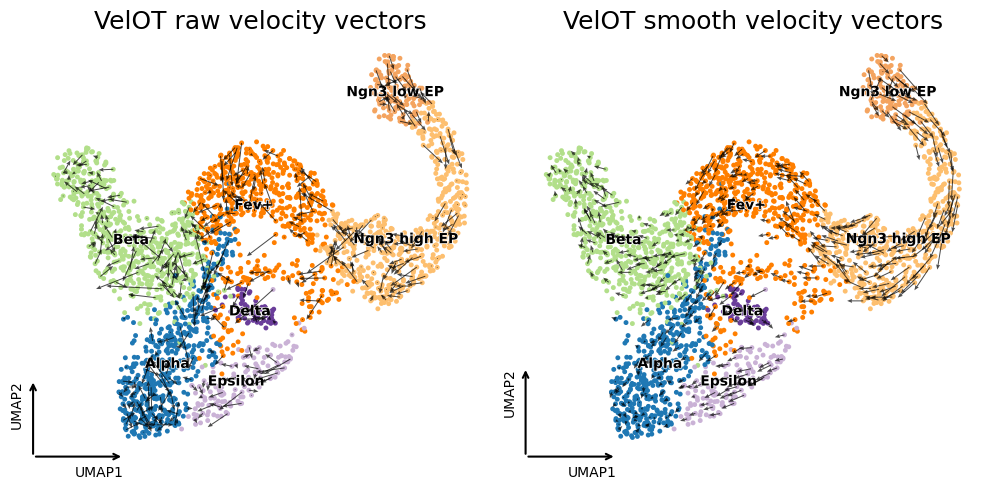

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

velot.pl.velocity_quiver(adata,
    color=clusters_key, basis="umap", subsample=500,
    velocity_key=f"velot_velocity_raw_umap",
    title="VelOT raw velocity vectors",
    show=False, ax=axes[0]
)
velot.pl.velocity_quiver(adata,
    color=clusters_key, basis="umap", subsample=500,
    velocity_key=f"velot_velocity_umap",
    title="VelOT smooth velocity vectors",
    show=False, ax=axes[1]
)

plt.tight_layout()
plt.show()

## CBDir & ICCoh metrics

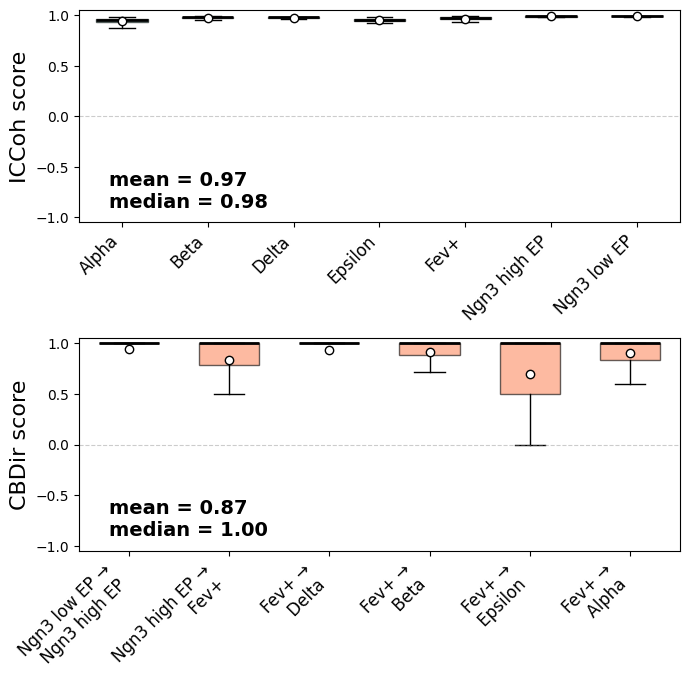

In [8]:
edges = [
    ('Ngn3 low EP', 'Ngn3 high EP'), 
    ('Ngn3 high EP', 'Fev+'),
    ('Fev+', 'Delta'), 
    ('Fev+', 'Beta'),
    ('Fev+','Epsilon'),
    ('Fev+','Alpha')
]
results = velot.metrics.summary(adata,
    cluster_edges=edges, cluster_key=clusters_key,
    embedding_key=f"X_{basis}", velocity_key=f"velot_velocity_{basis}",
    print_results=False
)
velot.pl.metric_summary(results,
    orientation="vertical", layout="column",
    figsize=(7,7), show=show
)

## Further analysis

### Windows construction for OT solve

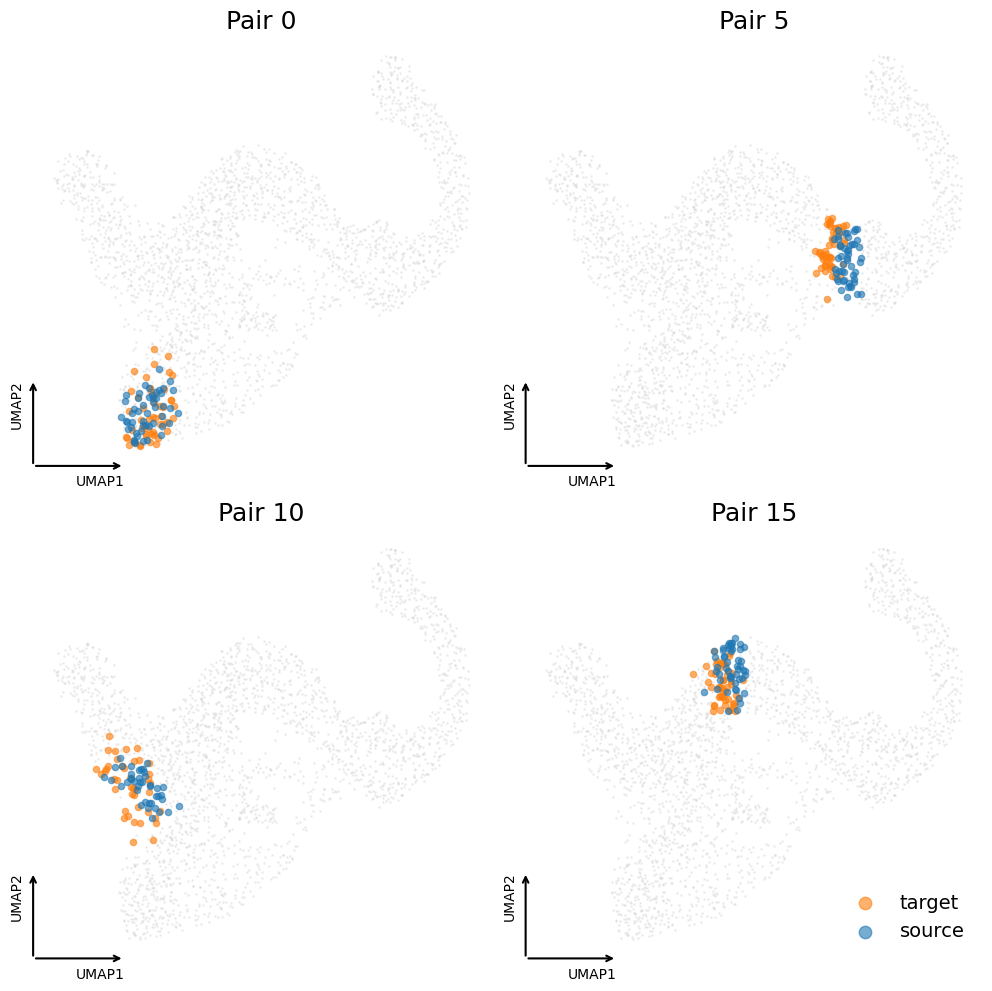

In [9]:
n_total_pairs = adata.uns["velot_windows"]["n_pairs"]
pairs_to_show = tuple([i*5 for i in range(n_total_pairs)])
velot.pl.windows(adata, basis="umap",
    pairs_to_show=pairs_to_show[:4], ncols=2,
    pair_title=True, figsize_per_panel=(5,5), show=show
)

### Training curves for the smoothing step

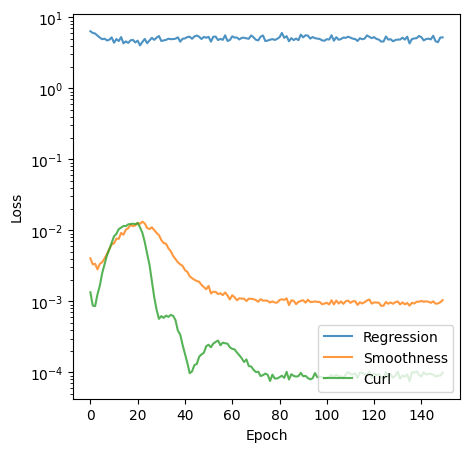

In [10]:
velot.pl.training_curves_single(adata, figsize=(5,5), show=show)